[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geraldmc/irilab2026/blob/main/example/Grad_CAM/grad_cam.ipynb)

## Grad-CAM example

Grad-CAM (Selvaraju et al., 2017) answers a simple question: when a neural network looks at an image and makes a guess, *which parts of the image* did it use? The answer comes back as a heatmap — a colored overlay that glows where the model paid the most attention.

This matters because a model can be right for the wrong reason. A plant-disease model might "diagnose" a leaf by reading the soil in the background instead of the lesion. Grad-CAM is how we check.

In this notebook you'll build Grad-CAM from scratch on a single image, one step at a time, and finish with a heatmap painted over the original photo.

### 1) Get set up

These first cells prepare your workspace: they mount your Google Drive, download the project code from GitHub, and load a few helper functions for displaying images.

One heads-up: the `rm -rf irilab2026` cell *deletes* the project folder. It's there for when you need to restart the download. Skip it unless something went wrong with the clone.

In [125]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [128]:
import os

repo_url = "https://github.com/geraldmc/irilab2026.git"
repo_name = "irilab2026" # The folder created when you clone

if not os.path.exists(repo_name):
    print(f"Cloning {repo_name}...")
    !git clone $repo_url
else:
    print(f"{repo_name} already exists. Skipping clone.")

Cloning irilab2026...
Cloning into 'irilab2026'...
remote: Enumerating objects: 1951, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 1951 (delta 83), reused 100 (delta 57), pack-reused 1814 (from 1)
Receiving objects: 100% (1951/1951), 13.24 MiB | 21.73 MiB/s, done.
Resolving deltas: 100% (1276/1276), done.


In [127]:
# 1. If necessary, remove the existing repository folder
# (replace 'repo-name' with your actual folder name) and rerun above cell.
!rm -rf irilab2026

In [129]:
# load some helper functions
%run /content/irilab2026/example/Grad_CAM/helper.py

<Figure size 640x480 with 0 Axes>

### 2) Load a trained model and a few images

We use VGG19, a well-known image classifier already trained on ImageNet (about a million everyday photos across 1000 categories). Because it's pre-trained, it already "knows" what elephants, sharks, and lizards look like — we don't have to train anything ourselves.

The `transform` resizes every image to 224×224 and normalizes its colors the exact way VGG19 expects. Our dataset is just five images sorted into three folders. The cell right after this loads one image and displays it, so you can confirm the pipeline works before going further.

In [130]:
import torch
import torch.nn as nn
from torch.utils import data
from torchvision import models
from torchvision import transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

# VGG19 is deep CNN architecture widely used for image recognition.
vgg19_model = models.vgg19(weights="DEFAULT")

# use the ImageNet transformation
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                     std=[0.229, 0.224, 0.225])])
# check the image path
def is_valid_image(path):
    # Only allow typical image extensions and skip hidden files
    valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm',
                        '.tif', '.tiff', '.webp')
    return path.lower().endswith(valid_extensions) and not os.path.basename(path).startswith('.')

# define a 5 image dataset
image_dir = "/content/irilab2026/example/Grad_CAM/my_dataset/"

dataset = datasets.ImageFolder(root=image_dir,
                               is_valid_file=is_valid_image, transform=transform)

dataloader = data.DataLoader(dataset=dataset, shuffle=False, batch_size=5)


<Axes: >

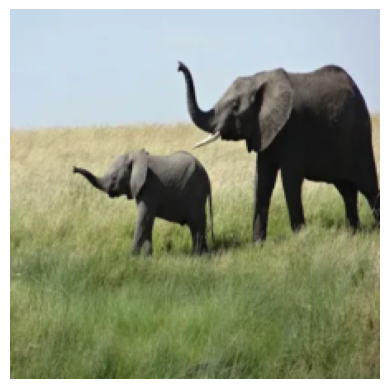

In [131]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=True)

### 3) Find the right place to look

Grad-CAM needs to gain access to one specific piece of the network: the **last convolutional layer**. Why there? Convolutional layers keep track of *where* things are in the image — their output is still laid out as a grid — while the fully-connected layers that come after it throw this spatial information away. The last convolutional layer is late enough to have learned meaningful, high-level features, but still holds a map of where those features are.

The cell below prints VGG19's layers so you can see them. The final block ends at index 36, and that's where we'll cut the network.

In [132]:
# We need to take a look at the VGG19 model's features, its architecture.
# VGG19 is deep CNN architecture widely used for image recognition and classification.
vgg19_model = models.vgg19(weights="DEFAULT")

vgg19_model.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

### 4) Rewire the model to watch that layer

Out of the box, VGG19 won't show us its inner gradients — it just hands back a prediction. So we wrap it in a small custom class that does two things.

First, it splits the network at the last convolutional layer (`features_conv`), so we can grab that layer's output. Second, it attaches a **hook** — a small function that quietly catches the gradients flowing back through that layer during backpropagation and stores them in `self.gradients`. Think of the hook as a tap installed on a pipe: the model runs normally, and as gradients flow past, we catch a copy.

The two helper methods at the bottom let us read out the saved gradients and the layer's activations later.

In [133]:
class myVGG(nn.Module):
    def __init__(self):
        super(myVGG, self).__init__()

        # get the pretrained VGG19 network
        self.vgg = models.vgg19(weights="DEFAULT")

        # disect the network to access its last convolutional layer
        self.features_conv = self.vgg.features[:36]

        # get the max pool of the features stem
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

        # get the classifier of the vgg19
        self.classifier = self.vgg.classifier

        # placeholder for the gradients
        self.gradients = None

    # hook for the gradients of the activations
    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        x = self.features_conv(x)

        # register the hook
        h = x.register_hook(self.activations_hook)

        # apply the remaining pooling
        x = self.max_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    # method for the gradient extraction
    def get_activations_gradient(self):
        return self.gradients

    # method for the activation exctraction
    def get_activations(self, x):
        return self.features_conv(x)

### 5) Make a prediction, then ask the model where it looked

First we run the image through our rewired model and see what it predicts. It lands on class 386 — *African elephant*. Then comes the heart of Grad-CAM: a five-step recipe that turns that prediction into a heatmap.

1. Push the elephant score backward to the last convolutional layer.
2. Turn those gradients into one importance weight per feature map.
3. Scale each feature map by its weight.
4. Add them up, and keep only what pushed the score *up*.
5. Tidy the result into a clean heatmap.

The cells take these one at a time — watch the shapes change as we go.

In [135]:
# initialize the VGG model
vgg = VGG()

# set the evaluation mode
vgg.eval()

# get the image from the dataloader
images, _ = next(iter(dataloader))

# keep the batch dimension: images[0:1] is (1, 3, 224, 224), not (3, 224, 224)
img = images[0:1]

# get the most likely prediction of the model
pred = vgg(img).argmax(dim=1)

This time we keep `pred = vgg(img)` as the **raw scores** for all 1000 classes (shape `(1, 1000)`), not the `argmax`. That's deliberate: in the next step we push gradients backward through the elephant score, and `argmax` has no gradient to push through — it only names the winning class. So we use `argmax` just to read off the class number (386), and keep the raw scores for the real work.

In [136]:
# get the raw class scores, shape (1, 1000)
pred = vgg(img)

# read off the most likely class — this is where the 386 comes from
pred.argmax(dim=1)        # -> tensor([386]), African elephant

tensor([386])

**Step 1 — push the score backward.** Calling `.backward()` on the elephant score (`pred[:, 386]`) runs backpropagation. Our hook catches the gradients at the last convolutional layer on the way past, and the cell after pulls them out — one gradient grid per feature map, shape `(1, 512, 14, 14)`.

In [137]:
pred[:, 386].backward()

In [138]:
# pull the gradients out of the model
gradients = vgg.get_activations_gradient()

**Step 2 — turn the gradients into importance weights.** Each of the 512 feature maps came back with a full grid of gradients. We don't need the grid — we need one number per map saying how much that feature mattered for *elephant*. Averaging each map's gradients down to a single value gives exactly that, with shape `(512,)`: one weight per channel.

In [139]:
# pool the gradients across the channels
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

**Step 3 — scale each feature map by its weight.** We pull the activations from that same convolutional layer (`get_activations`), then multiply each of the 512 maps by its importance weight from Step 2. Maps the model leaned on get amplified; maps it ignored get shrunk. The loop in the next cell does this one channel at a time.

In [140]:
# get the activations of the last convolutional layer
activations = vgg.get_activations(img).detach()

In [141]:
# weight the channels by corresponding gradients
for i in range(512):
    activations[:, i, :, :] *= pooled_gradients[i]

**Step 4 — add them up and keep the positives.** Averaging the weighted maps collapses all 512 channels into a single 14×14 grid. Then a ReLU keeps only the regions that pushed the elephant score *up* and zeroes out the rest — this is equation (2) in the Grad-CAM paper. What we drop matters: a feature that argued *against* elephant isn't part of why the model said elephant. (You may see a harmless NumPy warning when this runs — it's safe to ignore.)

In [142]:
# average the channels of the activations
heatmap = torch.mean(activations, dim=1).squeeze()

In [143]:
# relu on top of the heatmap
# expression (2) in https://arxiv.org/pdf/1610.02391.pdf
heatmap = np.maximum(heatmap, 0)

/tmp/ipykernel_4869/1678595836.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)


**Step 5 — tidy it into a heatmap.** Dividing by the largest value rescales everything to the range 0–1, so the hottest spot is exactly 1. Now it's a clean heatmap, ready to look at.

In [144]:
# normalize the heatmap
heatmap /= torch.max(heatmap)

### 6) See the answer

The first cell below draws the raw 14×14 heatmap — small and blocky, because that's the resolution of the last convolutional layer. The second shows the original photo for comparison. Bright areas are where the model focused when it decided "elephant." Side by side, these two are a little hard to line up by eye — which is exactly what the final stage fixes.

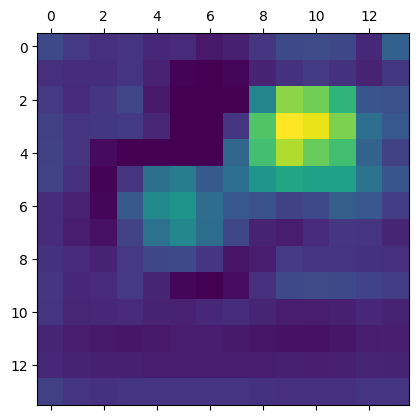

In [145]:
# draw the heatmap
plt.matshow(heatmap.squeeze())

<Axes: >

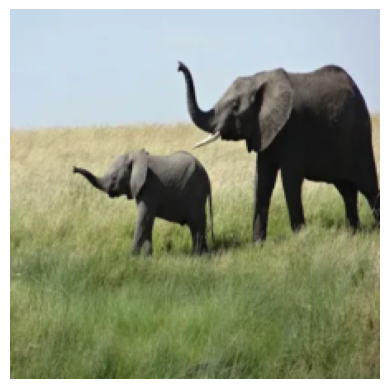

In [146]:
imshow(images[0], normalize=True)

### 7) Put the heatmap on top of the photo

Looking at the heatmap and the photo separately makes you do the matching in your head. The payoff is laying one over the other, so the glow sits directly on the part of the image the model used.

To do that we stretch the small 14×14 heatmap up to the full 224×224 image size, then draw it on top of the photo as a semi-transparent colored layer. Now you can read the model's attention at a glance.

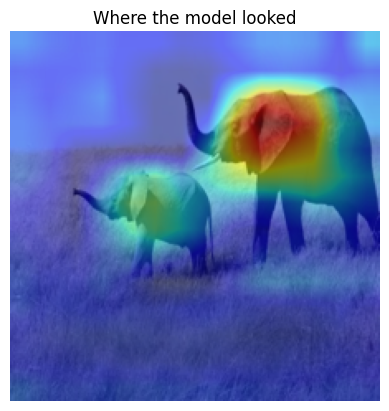

In [147]:
import torch.nn.functional as F

# make sure the heatmap is a float tensor we can resize
hm = torch.as_tensor(heatmap, dtype=torch.float32)

# stretch the small heatmap up to the image size (14x14 -> 224x224)
heatmap_big = F.interpolate(
    hm.reshape(1, 1, *hm.shape),        # add batch + channel dims: (1, 1, 14, 14)
    size=(224, 224),
    mode="bilinear",
    align_corners=False,
).squeeze().detach().numpy()

# undo the ImageNet normalization so the photo looks natural again
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
photo = images[0].numpy().transpose(1, 2, 0)
photo = np.clip(std * photo + mean, 0, 1)

# draw the photo, then the heatmap on top as a see-through colored layer
plt.imshow(photo)
plt.imshow(heatmap_big, cmap="jet", alpha=0.5)
plt.axis("off")
plt.title("Where the model looked")
plt.show()